# PEAK M-ATH — Detection of C&C Network Beaconing

Separate **command-and-control beaconing** (periodic or near-periodic check-ins) from ordinary application traffic using **inter-connection timing** on network flow or connection logs, following the **PEAK** framework: **Prepare → Execute → Act → Knowledge**. This hunt targets channels such as HTTP(S), SMB, named pipes, or other transports where adversaries maintain access with regular callbacks—not DNS specifically (see the DNS beaconing scenario for query periodicity).

**Ref:** M12 — Detection of C&C network beaconing  
**M-ATH sub-process:** Forecasting and anomaly detection — identify periodic communications that deviate from normal service patterns.  
**M-ATH approach:** Coefficient of variation (CV), burstiness, band/slow CV on inter-arrival intervals; optional RITA-style gates; exclusion-based FP management.

**Lineage:** This notebook is **CV-first** (with Zscaler-aware keys and band/slow paths). It also exports **Bowley skew**, **MADM**, and **events/hour** for analysis and optional **RITA-style** gates/ranking (`USE_RITA_STYLE_*` in the prioritize cell). For how this compares to [RITA](https://activecountermeasures.com/) / [RITA-J](https://github.com/Cyb3r-Monk/RITA-J), see the scenario README section *Related work and design choices*.

## Method (from scenario README)

1. **Load** — Read network telemetry from `input/`.
2. **Group** — Build periodicity keys: Zscaler-style rows with a target hostname use **egress identity (`flow_src`), hostname, port, and application protocol** (destination IP omitted so CDN-style backends stay one series **per egress**); otherwise **flow source, destination IP, port, and protocol**.
3. **Measure** — Derive timing regularity (inter-arrival intervals), frequency, and simple session shape.
4. **Prioritize** — Rank flows whose intervals look **too regular** for typical human-driven browsing (low relative spread).
5. **Investigate** — Validate with host/process context, destination ownership, and threat intelligence outside this notebook.

## Detection logic (interval regularity)

With **positive** inter-arrival gaps $\Delta_i = t_{i+1} - t_i$ (seconds), $N \ge 2$, use **population** standard deviation (`ddof=0` in code):

$$
\mu = \frac{1}{N}\sum_{i=1}^{N} \Delta_i,\qquad
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\Delta_i - \mu)^2}
$$

$$
\mathrm{CV} = \frac{\sigma}{\mu}\quad (\mu > 0),\qquad
B = \frac{\sigma - \mu}{\sigma + \mu}\quad (\sigma + \mu > 0)
$$

For each flow key, events are sorted by time and deduplicated per timestamp before gaps are taken. **Coefficient of variation** $\mathrm{CV} = \sigma / \mu$ measures relative jitter: sustained beaconing often shows **low CV** compared to bursty user traffic. **Burstiness** $B$ (above) is a complementary signal—very regular beacons tend toward **negative** $B$.

Thresholds below are **tunable hunt parameters**, not ground truth labels. Tune `MIN_EVENTS`, `MAX_CV`, and interval bounds to your environment. **Relaxed `MAX_CV`** applies only when **`UDM_INPUT_MODE`** is on (sparse UDM without Zscaler-style NAT + `application_protocol`); see the prioritize section.

## How to use

1. Place connection or flow logs in `input/` (CSV). When **`PRIMARY_INPUT_CSV` is `None`**, the load cell **concatenates every `*.csv` file** under `input/` (recursive subfolders, sorted by path). Set **`PRIMARY_INPUT_CSV`** to a single filename under `input/` if you want to restrict the run to one export.
2. Run all cells.
3. Review `output/c2_network_beaconing_candidates.csv`, the KPI chart `output/c2_network_beaconing_kpis.png`, and triage with SIEM or intel tools.

**Timestamps without a calendar year** (e.g. some console-formatted exports) are interpreted using `DEFAULT_EVENT_YEAR` in the load cell.

In [21]:
print('Run the next cell to set repository paths and scenario input/output directories.')

Run the next cell to set repository paths and scenario input/output directories.


## PREPARE — Plan your Approach

- **Select Topic:** C&C network beaconing — adversaries maintain persistence via periodic callbacks over HTTP(S), SMB, or other channels (MITRE ATT&CK [T1071](https://attack.mitre.org/techniques/T1071/) Application Layer Protocol, [T1573](https://attack.mitre.org/techniques/T1573/) Encrypted Channel).
- **Research Topic:** Inter-arrival timing statistics (CV, burstiness, Bowley skew, MADM), RITA-style beaconing gates, Zscaler/UDM flow grouping.
- **Identify Datasets:** Network flow or connection logs from SIEM, EDR, or proxy (Zscaler, UDM); exclusion configs for known benign periodic flows.
- **Select Algorithms:** Coefficient of variation on inter-arrival gaps (classic, band, slow variants), burstiness index, optional RITA-style composite gates, threshold-based prioritization with exclusion overlay.

In [22]:
# Scenario mode: anchor paths to this notebook's scenario folder.
import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'detection_logics').exists() and (cur / 'scenarios').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Unable to locate repository root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
SCENARIO_DIR = REPO_ROOT / 'scenarios' / 'detection_of_c2_network_beaconing'
if not SCENARIO_DIR.exists():
    raise FileNotFoundError(f'Scenario folder not found: {SCENARIO_DIR.relative_to(REPO_ROOT)}')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

INPUT_DIR = SCENARIO_DIR / 'input'
OUTPUT_DIR = SCENARIO_DIR / 'output'
REPO_EXCLUSIONS_DIR = REPO_ROOT / 'exclusions'
SCENARIO_EXCLUSIONS_DIR = SCENARIO_DIR / 'exclusions'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SCENARIO_MODE = True
print(f'Scenario folder: {SCENARIO_DIR.relative_to(REPO_ROOT)}')

Scenario folder: scenarios\detection_of_c2_network_beaconing


In [23]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 120)

if not globals().get('SCENARIO_MODE', False):
    INPUT_DIR = Path('input')
    OUTPUT_DIR = Path('output')
    REPO_EXCLUSIONS_DIR = Path('exclusions')
    SCENARIO_EXCLUSIONS_DIR = Path('exclusions')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_VALUES_REPO = REPO_EXCLUSIONS_DIR / 'excluded_values.conf'
EXCLUDED_REASONS_REPO = REPO_EXCLUSIONS_DIR / 'excluded_values+reasons.conf'
EXCLUDED_VALUES_SCENARIO = SCENARIO_EXCLUSIONS_DIR / 'excluded_values.conf'
EXCLUDED_REASONS_SCENARIO = SCENARIO_EXCLUSIONS_DIR / 'excluded_values+reasons.conf'
EXCLUDED_VALUES_COMPANY_SPECIFIC = SCENARIO_EXCLUSIONS_DIR / 'excluded_values-company-specific.conf'
REVIEWED_VALUES_REPO = REPO_EXCLUSIONS_DIR / 'reviewed_values.conf'
REVIEWED_VALUES_SCENARIO = SCENARIO_EXCLUSIONS_DIR / 'reviewed_values.conf'


def _rel(p):
    try:
        if globals().get('SCENARIO_MODE', False) and 'REPO_ROOT' in globals():
            root = globals()['REPO_ROOT']
            if hasattr(p, 'is_relative_to') and p.is_relative_to(root):
                return p.relative_to(root)
        return p
    except (ValueError, AttributeError):
        return p


def normalize_exclusion_value(value):
    return str(value or '').strip().lower().rstrip('.')


def read_conf_lines(path: Path):
    if not path.exists():
        return []
    lines = []
    with path.open('r', encoding='utf-8') as handle:
        for raw in handle:
            line = raw.split('#', 1)[0].strip()
            if not line:
                continue
            lines.append(line)
    return lines


def load_exclusions_from_files(values_file: Path, value_reason_file: Path):
    excluded_values = {
        normalize_exclusion_value(v)
        for v in read_conf_lines(values_file)
        if normalize_exclusion_value(v)
    }
    excluded_pairs = set()
    for line in read_conf_lines(value_reason_file):
        if '||' not in line:
            continue
        value_part, reason_part = line.split('||', 1)
        v_norm = normalize_exclusion_value(value_part)
        r_norm = str(reason_part or '').strip().lower()
        if v_norm and r_norm:
            excluded_pairs.add((v_norm, r_norm))
    return excluded_values, excluded_pairs


def merge_exclusions():
    v1, p1 = load_exclusions_from_files(EXCLUDED_VALUES_REPO, EXCLUDED_REASONS_REPO)
    v2, p2 = load_exclusions_from_files(EXCLUDED_VALUES_SCENARIO, EXCLUDED_REASONS_SCENARIO)
    v3 = {
        normalize_exclusion_value(v)
        for v in read_conf_lines(EXCLUDED_VALUES_COMPANY_SPECIFIC)
        if normalize_exclusion_value(v)
    }
    return v1 | v2 | v3, p1 | p2


def is_excluded_dst(dst_value, reasons, excluded_values, excluded_pairs):
    """Match destination IP or hostname against merged repo + scenario exclusion lists."""
    value_norm = normalize_exclusion_value(dst_value)
    if not value_norm:
        return False
    reason_list = [str(r or '').strip().lower() for r in reasons]
    if value_norm in excluded_values:
        return True
    for reason in reason_list:
        if (value_norm, reason) in excluded_pairs:
            return True
    return False


excluded_values_cfg, excluded_value_reason_cfg = merge_exclusions()

if not EXCLUDED_VALUES_COMPANY_SPECIFIC.exists():
    import warnings
    warnings.warn(
        f"\n"
        f"⚠️  Company-specific exclusions file not found:\n"
        f"     {_rel(EXCLUDED_VALUES_COMPANY_SPECIFIC)}\n"
        f"   Organisation-specific domains (corporate, subsidiaries, internal suffixes) will NOT be excluded.\n"
        f"   Create the file from the provided example:\n"
        f"     cp {_rel(EXCLUDED_VALUES_COMPANY_SPECIFIC)}.example \\\n"
        f"        {_rel(EXCLUDED_VALUES_COMPANY_SPECIFIC)}",
        UserWarning,
        stacklevel=2,
    )

reviewed_values_cfg = set()
for _rv_path in (REVIEWED_VALUES_REPO, REVIEWED_VALUES_SCENARIO):
    for v in read_conf_lines(_rv_path):
        _v = normalize_exclusion_value(v)
        if _v:
            reviewed_values_cfg.add(_v)

print(f'Input folder: {_rel(INPUT_DIR)}')
print(f'Output folder: {_rel(OUTPUT_DIR)}')
print(f'Exclusions (repo): {_rel(EXCLUDED_VALUES_REPO)}; scenario: {_rel(EXCLUDED_VALUES_SCENARIO)}'
      f'; company-specific: {_rel(EXCLUDED_VALUES_COMPANY_SPECIFIC)} ({"found" if EXCLUDED_VALUES_COMPANY_SPECIFIC.exists() else "NOT FOUND — see warning above"})')
print(f'Exclusion entries loaded: values={len(excluded_values_cfg)}, value+reason pairs={len(excluded_value_reason_cfg)}')
print(f'Reviewed values (kept in findings): {len(reviewed_values_cfg)}')

Input folder: scenarios\detection_of_c2_network_beaconing\input
Output folder: scenarios\detection_of_c2_network_beaconing\output
Exclusions (repo): exclusions\excluded_values.conf; scenario: scenarios\detection_of_c2_network_beaconing\exclusions\excluded_values.conf; company-specific: scenarios\detection_of_c2_network_beaconing\exclusions\excluded_values-company-specific.conf (found)
Exclusion entries loaded: values=57, value+reason pairs=0
Reviewed values (kept in findings): 0


## EXECUTE — Experimentation Time

- **Gather Data:** Load network flow CSVs from `input/`, map columns to a common schema.
- **Pre-Process Data:** Build periodicity keys (grouping by source, destination, port, protocol), compute inter-arrival intervals, deduplicate timestamps.
- **Apply:** Calculate CV, band/slow CV, burstiness, and optional RITA-style metrics per flow group.
- **Analyze:** Prioritize candidates with low CV (regular intervals), apply threshold gates and exclusions.
- **Escalate Critical Findings:** Flows with very low CV and high event counts warrant immediate investigation for active C2 channels.

## Load network flow data

CSV column names are **auto-detected** from common exports:

- **Sentinel / generic SIEM:** `src.ip.address`, `dst.ip.address`, `event.time`, `event.network.protocolName`, etc.
- **Chronicle / SecOps UDM-style:** `timestamp`, `udm.target.ip`, `udm.network.ip_protocol` (and optional `udm.target.port`, `udm.principal.ip` when present).
- **Zscaler (ingested as UDM / HTTP):** often includes **`udm.principal.nat_ip`** (user egress), **`udm.network.application_protocol`** (`HTTP` / `HTTPS`), and **`udm.target.asset.hostname`**. There is usually **no L4 port column**; the notebook **infers 80/443** from the application protocol for grouping. When a **target hostname** is present, periodicity uses **`(flow_src, hostname, port, protocol)`** (not `udm.target.ip`) so **multiple backend IPs per hostname** still form one series **per egress NAT**.

Inputs: **`PRIMARY_INPUT_CSV`** loads one file by name under `input/`; if it is **`None`**, the notebook loads **every `*.csv`** under `input/` recursively (sorted), then concatenates them.

**UDM note:** Exports without **source IP** use a placeholder (`__unknown_src__`) and **relaxed CV** thresholds. **Zscaler-style** rows (NAT IP + application protocol) use **stricter** thresholds like generic SIEM exports.

In [24]:
DEFAULT_EVENT_YEAR = 2026  # Used when timestamps omit the year (some formatted exports)

# Set to one CSV filename under input/ to load only that file; None loads every *.csv under input/ (recursive).
PRIMARY_INPUT_CSV = None
UNKNOWN_SRC_LABEL = '__unknown_src__'
UNKNOWN_PORT = 0
USED_PRIMARY_UDM_FILE = False
RESOLVED_PRIMARY_NAME = None


def coerce_network_time(series: pd.Series, default_year: int = DEFAULT_EVENT_YEAR) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.str.replace('\u00b7', ' ', regex=False).str.replace('·', ' ', regex=False)
    has_4digit_year = s.str.contains(r'\b(?:19|20)\d{2}\b', regex=True)
    s_fixed = s.where(has_4digit_year, str(default_year) + ' ' + s)
    return pd.to_datetime(s_fixed, errors='coerce', utc=True)


def pick_column(columns: list[str], candidates: list[str]) -> str | None:
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for c in columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl.replace('_', '.').replace(' ', '.'):
                return c
    return None


if PRIMARY_INPUT_CSV:
    primary_path = INPUT_DIR / PRIMARY_INPUT_CSV
    if primary_path.is_file():
        csv_paths = [str(primary_path)]
        USED_PRIMARY_UDM_FILE = True
        RESOLVED_PRIMARY_NAME = PRIMARY_INPUT_CSV
        print(f'Using primary input: {_rel(primary_path)}')
    else:
        csv_paths = sorted(glob.glob(str(INPUT_DIR / '**' / '*.csv'), recursive=True))
        print(f'Warning: PRIMARY_INPUT_CSV not found ({PRIMARY_INPUT_CSV}); loading all CSVs ({len(csv_paths)}).')
        if csv_paths:
            USED_PRIMARY_UDM_FILE = True
            RESOLVED_PRIMARY_NAME = Path(csv_paths[0]).name
else:
    csv_paths = sorted(glob.glob(str(INPUT_DIR / '**' / '*.csv'), recursive=True))
    if csv_paths:
        USED_PRIMARY_UDM_FILE = True
        RESOLVED_PRIMARY_NAME = Path(csv_paths[0]).name
        print(f'Loading every CSV under {_rel(INPUT_DIR)} ({len(csv_paths)} file(s), sorted):')
        for _cp in csv_paths:
            print(f'  - {_rel(Path(_cp))}')

print(f'Found {len(csv_paths)} CSV file(s) to load.')

if not csv_paths:
    raise FileNotFoundError(
        f'No CSV files in {_rel(INPUT_DIR)}. Add network flow/connection exports (timestamp, src, dst, port, protocol).'
    )

dfs = []
for p in csv_paths:
    df = pd.read_csv(p)
    try:
        src_rel = (
            str(Path(p).relative_to(REPO_ROOT))
            if 'REPO_ROOT' in globals() and Path(p).is_relative_to(REPO_ROOT)
            else p
        )
    except (ValueError, AttributeError):
        src_rel = p
    df['_source_file'] = src_rel
    dfs.append(df)
raw = pd.concat(dfs, ignore_index=True)

time_col = pick_column(
    list(raw.columns),
    ['_time', 'event.time', 'timestamp', '@timestamp', 'time', 'event_time', 'start_time', 'metadata.event_timestamp'],
)
src_col = pick_column(
    list(raw.columns),
    [
        'src.ip.address',
        'source.ip',
        'src_ip',
        'client.ip',
        'origin.ip',
        'udm.principal.ip',
        'udm.principal.nat_ip',
        'principal.ip',
        'principal.nat_ip',
        'udm.principal.asset_ip',
    ],
)
dst_col = pick_column(
    list(raw.columns),
    [
        'dst.ip.address',
        'destination.ip',
        'dest.ip',
        'dst_ip',
        'server.ip',
        'target.ip',
        'udm.target.ip',
        'network.connection.dst_ip',
    ],
)
port_col = pick_column(
    list(raw.columns),
    [
        'dst.port.number',
        'destination.port',
        'dst_port',
        'dport',
        'server.port',
        'udm.target.port',
        'target.port',
        'network.target_port',
        'network.connection.dst_port',
    ],
)
proto_col = pick_column(
    list(raw.columns),
    [
        'event.network.protocolName',
        'protocol',
        'proto',
        'network.protocol',
        'app.protocol',
        'udm.network.ip_protocol',
        'udm.network.application_protocol',
        'network.application_protocol',
        'ip_protocol',
    ],
)
endpoint_col = pick_column(
    list(raw.columns),
    [
        'agent.uuid',
        'endpoint.name',
        'host.name',
        'device.name',
        'computer.name',
        'udm.principal.hostname',
        'principal.hostname',
        'udm.principal.asset_hostname',
    ],
)
hostname_col = pick_column(
    list(raw.columns),
    [
        'udm.target.asset.hostname',
        'target.asset.hostname',
        'target.hostname',
        'dst.hostname',
    ],
)
http_method_col = pick_column(
    list(raw.columns),
    [
        'udm.network.http.method',
        'network.http.method',
        'http.method',
        'http_method',
        'request.method',
    ],
)

missing = [n for n, c in [('time', time_col), ('dst', dst_col)] if not c]
if missing:
    raise ValueError(f'Missing required column(s) {missing}. Available: {list(raw.columns)}')

if not proto_col:
    raw['_protocol'] = 'unknown'
    proto_col = '_protocol'

raw['_time'] = coerce_network_time(raw[time_col])
raw['dst_ip'] = raw[dst_col].astype(str).str.strip()

if src_col:
    raw['src_ip'] = raw[src_col].astype(str).str.strip()
else:
    raw['src_ip'] = UNKNOWN_SRC_LABEL
    print(f'No source IP column; using src_ip={UNKNOWN_SRC_LABEL!r} (export-scoped grouping).')

raw['protocol'] = raw[proto_col].astype(str).str.strip().str.lower()
raw.loc[raw['protocol'].isin({'', 'nan', 'none'}), 'protocol'] = 'unknown'

if port_col:
    raw['dst_port'] = pd.to_numeric(raw[port_col], errors='coerce').fillna(UNKNOWN_PORT).astype(int)
else:

    def _infer_port_from_app(proto: str) -> int:
        p = (proto or '').strip().lower()
        if p in ('https', 'tls', 'ssl'):
            return 443
        if p == 'http':
            return 80
        if p in ('quic', 'http3', 'http/3'):
            return 443
        return UNKNOWN_PORT

    raw['dst_port'] = raw['protocol'].map(_infer_port_from_app)
    if (raw['dst_port'] != UNKNOWN_PORT).any():
        print(
            'No L4 port column: inferred dst_port 80/443 from application protocol '
            '(Zscaler / HTTP-style UDM).'
        )
    else:
        print(f'No destination port column; dst_port={UNKNOWN_PORT} when protocol is not http(s).')

if endpoint_col and endpoint_col in raw.columns:
    raw['flow_src'] = raw[endpoint_col].astype(str).str.strip()
    blank_ep = raw['flow_src'].isin({'', 'nan', 'none'})
    if blank_ep.any():
        raw.loc[blank_ep, 'flow_src'] = raw.loc[blank_ep, 'src_ip']
else:
    raw['flow_src'] = raw['src_ip']

if hostname_col:
    raw['dst_hostname'] = raw[hostname_col].astype(str).str.strip()
else:
    raw['dst_hostname'] = ''

if http_method_col:
    raw['http_method'] = raw[http_method_col].astype(str).str.strip()
    raw.loc[raw['http_method'].str.lower().isin({'', 'nan', 'none'}), 'http_method'] = ''
else:
    raw['http_method'] = ''

raw = raw.dropna(subset=['_time'])
raw = raw[raw['dst_ip'].str.len() > 0]
raw = raw[~raw['dst_ip'].isin({'nan', 'none'})]

keep_cols = [
    'flow_src',
    'src_ip',
    'dst_ip',
    'dst_port',
    'protocol',
    'dst_hostname',
    'http_method',
    '_time',
    '_source_file',
]
raw = raw[keep_cols].copy()

nat_src = raw['src_ip'].isin({'0.0.0.0', '::', '', UNKNOWN_SRC_LABEL})
if nat_src.all() or nat_src.mean() > 0.5:
    print('Note: majority or all rows lack a real source IP; beaconing groups are per (flow_src, dst, port, protocol) within this export.')

ZSCALER_STYLE_UDM = bool(
    src_col is not None
    and 'nat_ip' in str(src_col).lower()
    and proto_col is not None
    and 'application_protocol' in str(proto_col).lower()
)
# Relaxed CV only for sparse UDM (target IP, no Zscaler-style NAT + L7 protocol).
UDM_INPUT_MODE = bool(
    USED_PRIMARY_UDM_FILE
    and dst_col is not None
    and 'udm.target' in str(dst_col).lower()
    and not ZSCALER_STYLE_UDM
)

_PK_SEP = '\x1f'
if ZSCALER_STYLE_UDM:
    _hn = raw['dst_hostname'].fillna('').astype(str).str.strip()
    _has_hn = _hn.str.len() > 0
    _key_nat = (
        raw['flow_src'].astype(str)
        + _PK_SEP
        + raw['dst_ip'].astype(str)
        + _PK_SEP
        + raw['dst_port'].astype(str)
        + _PK_SEP
        + raw['protocol']
    )
    _key_host = (
        raw['flow_src'].astype(str)
        + _PK_SEP
        + _hn.str.lower()
        + _PK_SEP
        + raw['dst_port'].astype(str)
        + _PK_SEP
        + raw['protocol']
    )
    raw['_period_key'] = np.where(_has_hn, _key_host, _key_nat)
    if bool(_has_hn.any()):
        print(
            'Zscaler HTTP/S: rows with a target hostname use '
            '(flow_src, hostname, dst_port, protocol) for timing: same CDN hostname '
            'across different egress NAT IPs stays separate (no interleaved beacons), '
            'and destination IP is still omitted from the key so backend IP rotation '
            'does not fragment one logical series.'
        )
else:
    raw['_period_key'] = (
        raw['flow_src'].astype(str)
        + _PK_SEP
        + raw['dst_ip'].astype(str)
        + _PK_SEP
        + raw['dst_port'].astype(str)
        + _PK_SEP
        + raw['protocol']
    )

print(f'Loaded {len(raw):,} connection rows from {len(csv_paths)} file(s).')
print(
    f'Using columns: time={time_col!r}, src={src_col!r}, dst={dst_col!r}, '
    f'port={port_col!r}, proto={proto_col!r}, endpoint={endpoint_col!r}, '
    f'hostname={hostname_col!r}'
)
print(f'Zscaler-style UDM (NAT + application_protocol): {ZSCALER_STYLE_UDM}')
print(f'Relaxed UDM CV preset (no Zscaler-style columns): {UDM_INPUT_MODE}')

Loading every CSV under scenarios\detection_of_c2_network_beaconing\input (6 file(s), sorted):
  - scenarios\detection_of_c2_network_beaconing\input\UDM Events - 2026-03-24 08_25_14--beaconing-http.csv
  - scenarios\detection_of_c2_network_beaconing\input\UDM Events - 2026-03-24 09_37_58--beaconing-http.csv
  - scenarios\detection_of_c2_network_beaconing\input\UDM Events - 2026-03-25 13_19_56--beaconing-https.csv
  - scenarios\detection_of_c2_network_beaconing\input\synthetic_zscaler_noise_with_periodic-1.csv
  - scenarios\detection_of_c2_network_beaconing\input\synthetic_zscaler_noise_with_periodic-2.csv
  - scenarios\detection_of_c2_network_beaconing\input\synthetic_zscaler_noise_with_periodic-3.csv
Found 6 CSV file(s) to load.
No L4 port column: inferred dst_port 80/443 from application protocol (Zscaler / HTTP-style UDM).
Zscaler HTTP/S: rows with a target hostname use (flow_src, hostname, dst_port, protocol) for timing: same CDN hostname across different egress NAT IPs stays separ

## Group flows and compute periodicity metrics

Default flow key is **`(flow_src, dst_ip, dst_port, protocol)`**. For **Zscaler-style** exports (NAT IP + application protocol), rows with a non-empty **target hostname** use **`(flow_src, hostname, dst_port, protocol)`**—**no `dst_ip` in the key**—so **independent beacons from different egress NATs** are not interleaved into one jittery timeline, while **several backend IPs for the same SNI** still collapse into one series per egress.

Inter-arrival times use **seconds since UNIX epoch** from event time (correct for `datetime64[ns]` and `datetime64[us]` exports—avoid naive `int64 // 1e9` on microsecond columns).

Metrics: **mean**, **std**, **CV**, min/max, event count, **burstiness**, plus **band** and **slow-trimmed** CV helpers (used for Zscaler prioritization; see prioritize section). Every group also gets **Bowley skew** and **MADM** on all positive gaps, and **events per hour** over the observed span (first→last event). Optional **RITA-style** gates and blended ranking are in the prioritize cell (`USE_RITA_STYLE_*`, default off).

In [25]:
_EPOCH_UTC = pd.Timestamp('1970-01-01', tz='UTC')


def _mode_http_method(grp: pd.DataFrame) -> str:
    if 'http_method' not in grp.columns:
        return ''
    s = grp['http_method'].astype(str).str.strip()
    s = s[~s.str.lower().isin({'', 'nan', 'none', '<na>'})]
    s = s.dropna()
    if s.empty:
        return ''
    vc = s.value_counts(dropna=True)
    if len(vc) == 0:
        return ''
    return str(vc.index[0])


def compute_flow_beaconing_metrics(group: pd.DataFrame) -> dict | None:
    """Inter-arrival statistics for one periodicity group (see `_period_key` in load cell)."""
    group = group.sort_values('_time').drop_duplicates(subset=['_time'])
    if len(group) < 3:
        return None
    t = pd.to_datetime(group['_time'], utc=True, errors='coerce')
    ts_sec = ((t - _EPOCH_UTC) / pd.Timedelta(seconds=1)).to_numpy(dtype=np.float64)
    intervals = np.diff(ts_sec)
    intervals = intervals[intervals > 0]
    if len(intervals) < 2:
        return None
    mean_i = float(np.mean(intervals))
    std_i = float(np.std(intervals, ddof=0))
    median_i = float(np.median(intervals))
    cv = std_i / mean_i if mean_i > 0 else float('inf')
    burstiness = (std_i - mean_i) / (std_i + mean_i) if (std_i + mean_i) > 0 else float('nan')
    # Minute-scale beacon helper stats (no hostname/domain logic): dense HTTP/S logs often
    # mix sub-second gaps with ~60s check-ins; raw CV is then meaningless.
    _band_lo, _band_hi = 40.0, 95.0
    _slow_floor = 30.0
    ib = intervals[(intervals >= _band_lo) & (intervals <= _band_hi)]
    if len(ib) >= 2:
        mean_b = float(np.mean(ib))
        std_b = float(np.std(ib, ddof=0))
        cv_b = std_b / mean_b if mean_b > 0 else float('inf')
    else:
        mean_b = float('nan')
        cv_b = float('nan')
    islow = intervals[intervals >= _slow_floor]
    if len(islow) >= 2:
        med_s = float(np.median(islow))
        it = islow[islow <= 3.0 * med_s]
        if len(it) >= 2:
            mean_t = float(np.mean(it))
            std_t = float(np.std(it, ddof=0))
            cv_t = std_t / mean_t if mean_t > 0 else float('inf')
        else:
            mean_t = float('nan')
            cv_t = float('nan')
    else:
        mean_t = float('nan')
        cv_t = float('nan')
    return {
        'n_events': len(group),
        'n_intervals': len(intervals),
        'interval_mean_s': mean_i,
        'interval_median_s': median_i,
        'interval_std_s': std_i,
        'interval_cv': cv,
        'n_intervals_band': int(len(ib)),
        'interval_mean_band_s': mean_b,
        'interval_cv_band': cv_b,
        'n_intervals_slow': int(len(islow)),
        'interval_mean_slow_s': mean_t,
        'interval_cv_slow': cv_t,
        'interval_min_s': float(np.min(intervals)),
        'interval_max_s': float(np.max(intervals)),
        'burstiness': float(burstiness),
        'first_seen': group['_time'].min(),
        'last_seen': group['_time'].max(),
    }


results = []
for _pk, grp in raw.groupby('_period_key', sort=False):
    m = compute_flow_beaconing_metrics(grp)
    if not m:
        continue
    _hn = str(grp['dst_hostname'].iloc[-1]).strip() if 'dst_hostname' in grp.columns else ''
    if _hn.lower() in {'nan', 'none'}:
        _hn = ''
    _nats = sorted(grp['flow_src'].astype(str).unique())
    _flow_src_label = _nats[0] if len(_nats) == 1 else f'{len(_nats)}_nats'
    results.append(
        {
            'flow_src': _flow_src_label,
            'n_distinct_nat': len(_nats),
            'src_nat_ips': ','.join(_nats[:12]) + (f',+{len(_nats) - 12}' if len(_nats) > 12 else ''),
            'src_ip_sample': grp['src_ip'].iloc[-1],
            'dst_ip': grp['dst_ip'].iloc[-1],
            'n_distinct_dst_ip': int(grp['dst_ip'].nunique()),
            'dst_port': int(grp['dst_port'].iloc[-1]),
            'protocol': grp['protocol'].iloc[-1],
            'dst_hostname_sample': _hn,
            'http_method_sample': _mode_http_method(grp),
            **m,
        }
    )

_FLOW_COLUMNS = [
    'flow_src', 'n_distinct_nat', 'src_nat_ips', 'src_ip_sample',
    'dst_ip', 'n_distinct_dst_ip', 'dst_port', 'protocol', 'dst_hostname_sample', 'http_method_sample',
    'n_events', 'n_intervals', 'interval_mean_s', 'interval_median_s', 'interval_std_s',
    'interval_cv', 'n_intervals_band', 'interval_mean_band_s', 'interval_cv_band',
    'n_intervals_slow', 'interval_mean_slow_s', 'interval_cv_slow',
    'interval_min_s', 'interval_max_s', 'burstiness', 'first_seen', 'last_seen',
]
flows_df = pd.DataFrame(results)
if flows_df.empty:
    flows_df = pd.DataFrame(columns=_FLOW_COLUMNS)
print(f'Computed metrics for {len(flows_df):,} periodicity groups (_period_key).')

Computed metrics for 344 periodicity groups (_period_key).


## Prioritize beaconing candidates

Default filters favor **sustained**, **low-jitter** check-ins over a **bounded** mean inter-arrival time. **High-resolution** timestamps often show sub-second means (browser or resolver chatter); **raise `MIN_MEAN_S`** when you only care about minute-scale beacons. Coarse or bucketed logs can inflate apparent regularity—tune accordingly.

**Relaxed UDM preset:** When **`UDM_INPUT_MODE`** is true—primary CSV resolved, `udm.target.ip`, and **not** Zscaler-style (`udm.principal.nat_ip` + `udm.network.application_protocol`)—the notebook uses **relaxed `MAX_CV`** (~0.62). **Zscaler HTTP/S** exports use the **generic** preset (`MAX_CV` 0.36) because NAT IP and inferred ports 80/443 improve flow separation.

**Zscaler alternate scoring:** Dense proxy logs may yield meaningless raw CV when many sub-second gaps sit beside minute-scale check-ins. For **`ZSCALER_STYLE_UDM` only**, a row can also qualify via **`interval_cv_band`** (gaps in a tunable **40–95 s** band) or **`interval_cv_slow`** (gaps **≥ 30 s**, then drop outliers above **3×** the median of those slow gaps). Tune `MAX_CV_BAND`, `MAX_CV_SLOW`, and minimum interval counts in the code cell below.

**Optional RITA-style gates and ranking (defaults off):** Set **`USE_RITA_STYLE_GATES`** to require |Bowley skew|, MADM, and **events/hour** thresholds in addition to the CV rules. Set **`USE_RITA_STYLE_RANKING`** to sort candidates with a blend of minimum CV and a simple timing score (skew + MADM + connection density, inspired by [RITA-J](https://github.com/Cyb3r-Monk/RITA-J)). See the README section *Related work and design choices*.

**Exclusions:** merged **repository** `exclusions/` and this scenario's `exclusions/` (`excluded_values.conf` plus optional `excluded_values+reasons.conf`). Rows are dropped from the candidate set when **`dst_ip`** or **`dst_hostname_sample`** matches a listed value (normalized: lowercased, trailing dot stripped).

In [26]:
# Hunt parameters (tune per environment)
if globals().get('UDM_INPUT_MODE', False):
    # Chronicle UDM without Zscaler-style NAT + application_protocol: empirical CV floor often ~0.59+.
    MIN_EVENTS = 5
    MAX_CV = 0.62
    MIN_MEAN_S = 0.001
    MAX_MEAN_S = 7200
    EXCLUDE_PROTOCOLS: set[str] = {'null', 'unknown'}
    print(
        'Hunt parameters: relaxed UDM (no NAT/application_protocol) '
        f'(MAX_CV={MAX_CV}, MIN_MEAN_S={MIN_MEAN_S}).'
    )
else:
    MIN_EVENTS = 5
    MAX_CV = 0.36
    MIN_MEAN_S = 0.01
    MAX_MEAN_S = 7200
    EXCLUDE_PROTOCOLS = {'null', 'unknown'}
    _z = globals().get('ZSCALER_STYLE_UDM', False)
    print(
        'Hunt parameters: generic preset '
        f'(MAX_CV={MAX_CV}, MIN_MEAN_S={MIN_MEAN_S})'
        + (' - Zscaler / HTTP-style UDM (+ band/slow CV alternates)' if _z else ' - SIEM or full-fidelity flows')
        + '.'
    )

scored = flows_df.copy()
if EXCLUDE_PROTOCOLS:
    scored = scored[~scored['protocol'].isin({p.lower() for p in EXCLUDE_PROTOCOLS})]

_z_hunt = bool(globals().get('ZSCALER_STYLE_UDM', False))
# Zscaler HTTP/S: proxy logs often stack sub-second requests with minute-scale beacons; raw CV fails.
# Optional alternate passes use only gaps in a minute-scale band or a slow-gap + trimmed series.
CV_BAND_MIN_S = 40.0
CV_BAND_MAX_S = 95.0
MAX_CV_BAND = 0.38
MIN_INTERVALS_BAND = 25
SLOW_GAP_MIN_S = 30.0
MAX_CV_SLOW = 0.42
MIN_INTERVALS_SLOW = 25

mean_ok_full = (scored['interval_mean_s'] >= MIN_MEAN_S) & (scored['interval_mean_s'] <= MAX_MEAN_S)
cv_classic = scored['interval_cv'] <= MAX_CV
classic_hit = cv_classic & mean_ok_full

band_hit = pd.Series(False, index=scored.index)
slow_hit = pd.Series(False, index=scored.index)
if _z_hunt:
    mean_ok_band = (
        np.isfinite(scored['interval_mean_band_s'])
        & (scored['interval_mean_band_s'] >= MIN_MEAN_S)
        & (scored['interval_mean_band_s'] <= MAX_MEAN_S)
    )
    band_hit = (
        (scored['n_intervals_band'] >= MIN_INTERVALS_BAND)
        & np.isfinite(scored['interval_cv_band'])
        & (scored['interval_cv_band'] <= MAX_CV_BAND)
        & (scored['interval_mean_band_s'] >= CV_BAND_MIN_S * 0.75)
        & (scored['interval_mean_band_s'] <= CV_BAND_MAX_S * 1.25)
        & mean_ok_band
    )
    mean_ok_slow = (
        np.isfinite(scored['interval_mean_slow_s'])
        & (scored['interval_mean_slow_s'] >= MIN_MEAN_S)
        & (scored['interval_mean_slow_s'] <= MAX_MEAN_S)
    )
    slow_hit = (
        (scored['n_intervals_slow'] >= MIN_INTERVALS_SLOW)
        & np.isfinite(scored['interval_cv_slow'])
        & (scored['interval_cv_slow'] <= MAX_CV_SLOW)
        & mean_ok_slow
    )

mask = (scored['n_events'] >= MIN_EVENTS) & (classic_hit | band_hit | slow_hit)
candidates = scored[mask].copy()

keep_idx = []
for i, row in enumerate(candidates.itertuples(index=False)):
    reasons = []
    _hn = str(getattr(row, 'dst_hostname_sample', '') or '').strip()
    if is_excluded_dst(row.dst_ip, reasons, excluded_values_cfg, excluded_value_reason_cfg):
        continue
    if is_excluded_dst(_hn, reasons, excluded_values_cfg, excluded_value_reason_cfg):
        continue
    keep_idx.append(i)

candidates = candidates.iloc[keep_idx].reset_index(drop=True)

if len(candidates) > 0:
    _r_stack = np.column_stack(
        [
            candidates['interval_cv'].to_numpy(dtype=float),
            np.where(np.isfinite(candidates['interval_cv_band']), candidates['interval_cv_band'], np.nan),
            np.where(np.isfinite(candidates['interval_cv_slow']), candidates['interval_cv_slow'], np.nan),
        ]
    )
    candidates['best_interval_cv'] = np.nanmin(_r_stack, axis=1)

    # Destination-IP churn within a grouped flow: lower is more beacon-like consistency.
    _n_events = np.maximum(candidates['n_events'].to_numpy(dtype=float), 1.0)
    _n_dst = np.maximum(candidates['n_distinct_dst_ip'].to_numpy(dtype=float), 1.0)
    candidates['dst_ip_churn'] = np.clip(_n_dst / _n_events, 0.0, 1.0)

    _regularity_score = 1.0 - np.clip(candidates['best_interval_cv'].to_numpy(dtype=float), 0.0, 1.0)
    _event_density_score = np.clip(
        np.log1p(candidates['n_events'].to_numpy(dtype=float)) / np.log1p(5000.0),
        0.0,
        1.0,
    )
    _churn_stability_score = 1.0 / (1.0 + np.maximum(_n_dst - 1.0, 0.0))

    # Dual scoring for triage:
    # - tp_likelihood_score: high when periodicity is regular, dense, and destination-IP churn is low.
    # - benign_likelihood_score: high when timing is irregular and destination-IP churn is high.
    candidates['tp_likelihood_score'] = np.clip(
        0.50 * _regularity_score + 0.30 * _event_density_score + 0.20 * _churn_stability_score,
        0.0,
        1.0,
    )
    candidates['benign_likelihood_score'] = np.clip(
        0.55 * (1.0 - _regularity_score)
        + 0.35 * (1.0 - _churn_stability_score)
        + 0.10 * (1.0 - _event_density_score),
        0.0,
        1.0,
    )

    candidates = candidates.sort_values(
        ['tp_likelihood_score', 'benign_likelihood_score', 'best_interval_cv', 'interval_mean_s'],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)

candidates['rank'] = np.arange(1, len(candidates) + 1)

print(
    f"Flagged {len(candidates):,} flows (MIN_EVENTS={MIN_EVENTS}, MAX_CV={MAX_CV}, "
    f"mean interval [{MIN_MEAN_S}, {MAX_MEAN_S}] s"
    + ('; Zscaler rows may also match band/slow CV rules.' if _z_hunt else '')
    + ').'
)
if len(candidates) > 0:
    display(candidates.head(25))
else:
    print('No flows matched filters; relax thresholds or confirm timestamp granularity.')

# Optional lab QA only — not part of detection scoring (set to '' to disable).
LAB_QA_SUBSTRING = 'cstest'
if LAB_QA_SUBSTRING:
    _sub = LAB_QA_SUBSTRING.lower()
    _in_f = (
        flows_df['dst_hostname_sample']
        .fillna('')
        .astype(str)
        .str.lower()
        .str.contains(_sub, na=False)
    )
    print(
        f'Lab QA: flows with hostname containing {LAB_QA_SUBSTRING!r}: '
        f'{int(_in_f.sum())} / {len(flows_df)}'
    )
    if _in_f.any():
        display(
            flows_df.loc[_in_f, [
                'dst_ip', 'n_distinct_dst_ip', 'dst_port', 'protocol', 'dst_hostname_sample',
                'n_distinct_nat', 'n_events', 'interval_cv', 'interval_mean_s',
            ]].head(20)
        )
    if len(candidates) > 0:
        _in_c = (
            candidates['dst_hostname_sample']
            .fillna('')
            .astype(str)
            .str.lower()
            .str.contains(_sub, na=False)
        )
        print(
            f'Lab QA: candidates with hostname containing {LAB_QA_SUBSTRING!r}: '
            f'{int(_in_c.sum())} / {len(candidates)}'
        )

Hunt parameters: generic preset (MAX_CV=0.36, MIN_MEAN_S=0.01) - Zscaler / HTTP-style UDM (+ band/slow CV alternates).
Flagged 10 flows (MIN_EVENTS=5, MAX_CV=0.36, mean interval [0.01, 7200] s; Zscaler rows may also match band/slow CV rules.).


,flow_src,n_distinct_nat,src_nat_ips,src_ip_sample,dst_ip,n_distinct_dst_ip,dst_port,protocol,dst_hostname_sample,http_method_sample,...,interval_min_s,interval_max_s,burstiness,first_seen,last_seen,best_interval_cv,dst_ip_churn,tp_likelihood_score,benign_likelihood_score,rank
0,84.14.50.34,1,84.14.50.34,84.14.50.34,13.107.253.42,1,80,http,cobaltstrike-test.a03.azurefd.net,GET,...,60.0,420.0,-0.237098,2026-03-09 10:26:06+00:00,2026-03-09 12:36:13+00:00,0.003362,0.009259,0.863558,0.046769,1
1,84.14.50.34,1,84.14.50.34,84.14.50.34,13.107.253.42,1,443,https,cobaltstrike-test.a03.azurefd.net,GET,...,60.0,601.0,-0.072098,2026-03-17 08:21:18+00:00,2026-03-17 12:32:13+00:00,0.041497,0.006098,0.859093,0.062876,2
2,84.14.161.74,1,84.14.161.74,84.14.161.74,13.107.253.42,1,443,https,cobaltstrike-test.a03.azurefd.net,GET,...,60.0,3514.0,0.387061,2026-03-17 08:28:19+00:00,2026-03-17 12:31:13+00:00,0.004557,0.011494,0.855422,0.049939,3
3,84.14.50.34,1,84.14.50.34,84.14.50.34,13.107.246.42,3,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,GET,...,1.0,947691.0,0.976870,2026-03-04 15:50:09+00:00,2026-03-17 12:32:13+00:00,0.039630,0.000299,0.846852,0.255130,4
4,84.14.50.21,1,84.14.50.21,84.14.50.21,113.236.56.119,4,80,http,verymalicious2.c2.sim,GET,...,35.0,49.0,-0.813718,2026-03-01 00:00:00+00:00,2026-03-20 23:59:21+00:00,0.064361,0.000097,0.817820,0.297898,5
5,84.14.50.6,1,84.14.50.6,84.14.50.6,70.82.187.143,4,443,https,verymalicious3.c2.sim,GET,...,10.0,38.0,-0.486914,2026-03-07 00:00:00+00:00,2026-03-13 23:59:50+00:00,0.075645,0.000159,0.812177,0.304105,6
6,84.14.50.6,1,84.14.50.6,84.14.50.6,117.168.233.212,4,443,https,verymalicious1.c2.sim,GET,...,240.0,360.0,-0.796658,2026-03-20 19:17:20.340315+00:00,2026-03-25 19:14:11.340315+00:00,0.113178,0.002766,0.749731,0.339308,7
7,84.14.161.74,1,84.14.161.74,84.14.161.74,13.107.246.42,3,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,GET,...,2.0,948232.0,0.915911,2026-03-04 15:46:06+00:00,2026-03-17 12:31:13+00:00,0.140444,0.004208,0.727884,0.333431,8
8,84.14.50.34,1,84.14.50.34,84.14.50.34,13.107.246.42,14,443,https,mythic-test.a03.azurefd.net,GET,...,31.0,1112038.0,0.935034,2026-03-04 13:30:03+00:00,2026-03-18 08:32:24+00:00,0.235364,0.013712,0.640676,0.473093,9
9,84.14.161.74,1,84.14.161.74,84.14.161.74,13.107.213.42,10,443,https,mythic-test.a03.azurefd.net,GET,...,31.0,1111701.0,0.866913,2026-03-04 13:35:53+00:00,2026-03-18 08:33:34+00:00,0.229370,0.043860,0.596702,0.477358,10


Lab QA: flows with hostname containing 'cstest': 2 / 344


,dst_ip,n_distinct_dst_ip,dst_port,protocol,dst_hostname_sample,n_distinct_nat,n_events,interval_cv,interval_mean_s
50,13.107.246.42,3,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,1,10046,85.466515,110.634545
51,13.107.246.42,3,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,1,713,22.784304,1561.105337


Lab QA: candidates with hostname containing 'cstest': 2 / 10


## ACT — Wrapping Up the Investigation

- **Document Findings:** KPI charts and timeline visualizations summarize hunt outcomes — candidate counts, CV distributions, and temporal patterns.
- **Preserve Hunt:** Export ranked candidates CSV, KPI chart PNG, and false-positive candidates for downstream triage.
- **Create Detections / Playbooks:** High-confidence beaconing candidates (very low CV, high event count) can feed Risk-Based Alerting or scheduled detection rules; FP candidate triage improves exclusion lists for future runs.

## Hunt KPI charts

Summary figures are written to **`output/c2_network_beaconing_kpis.png`**, consistent with other scenario notebooks (e.g. punycode IDN KPI chart). The figure includes a **detections timeline**: each horizontal bar spans **first_seen → last_seen** for a flagged flow (UTC).

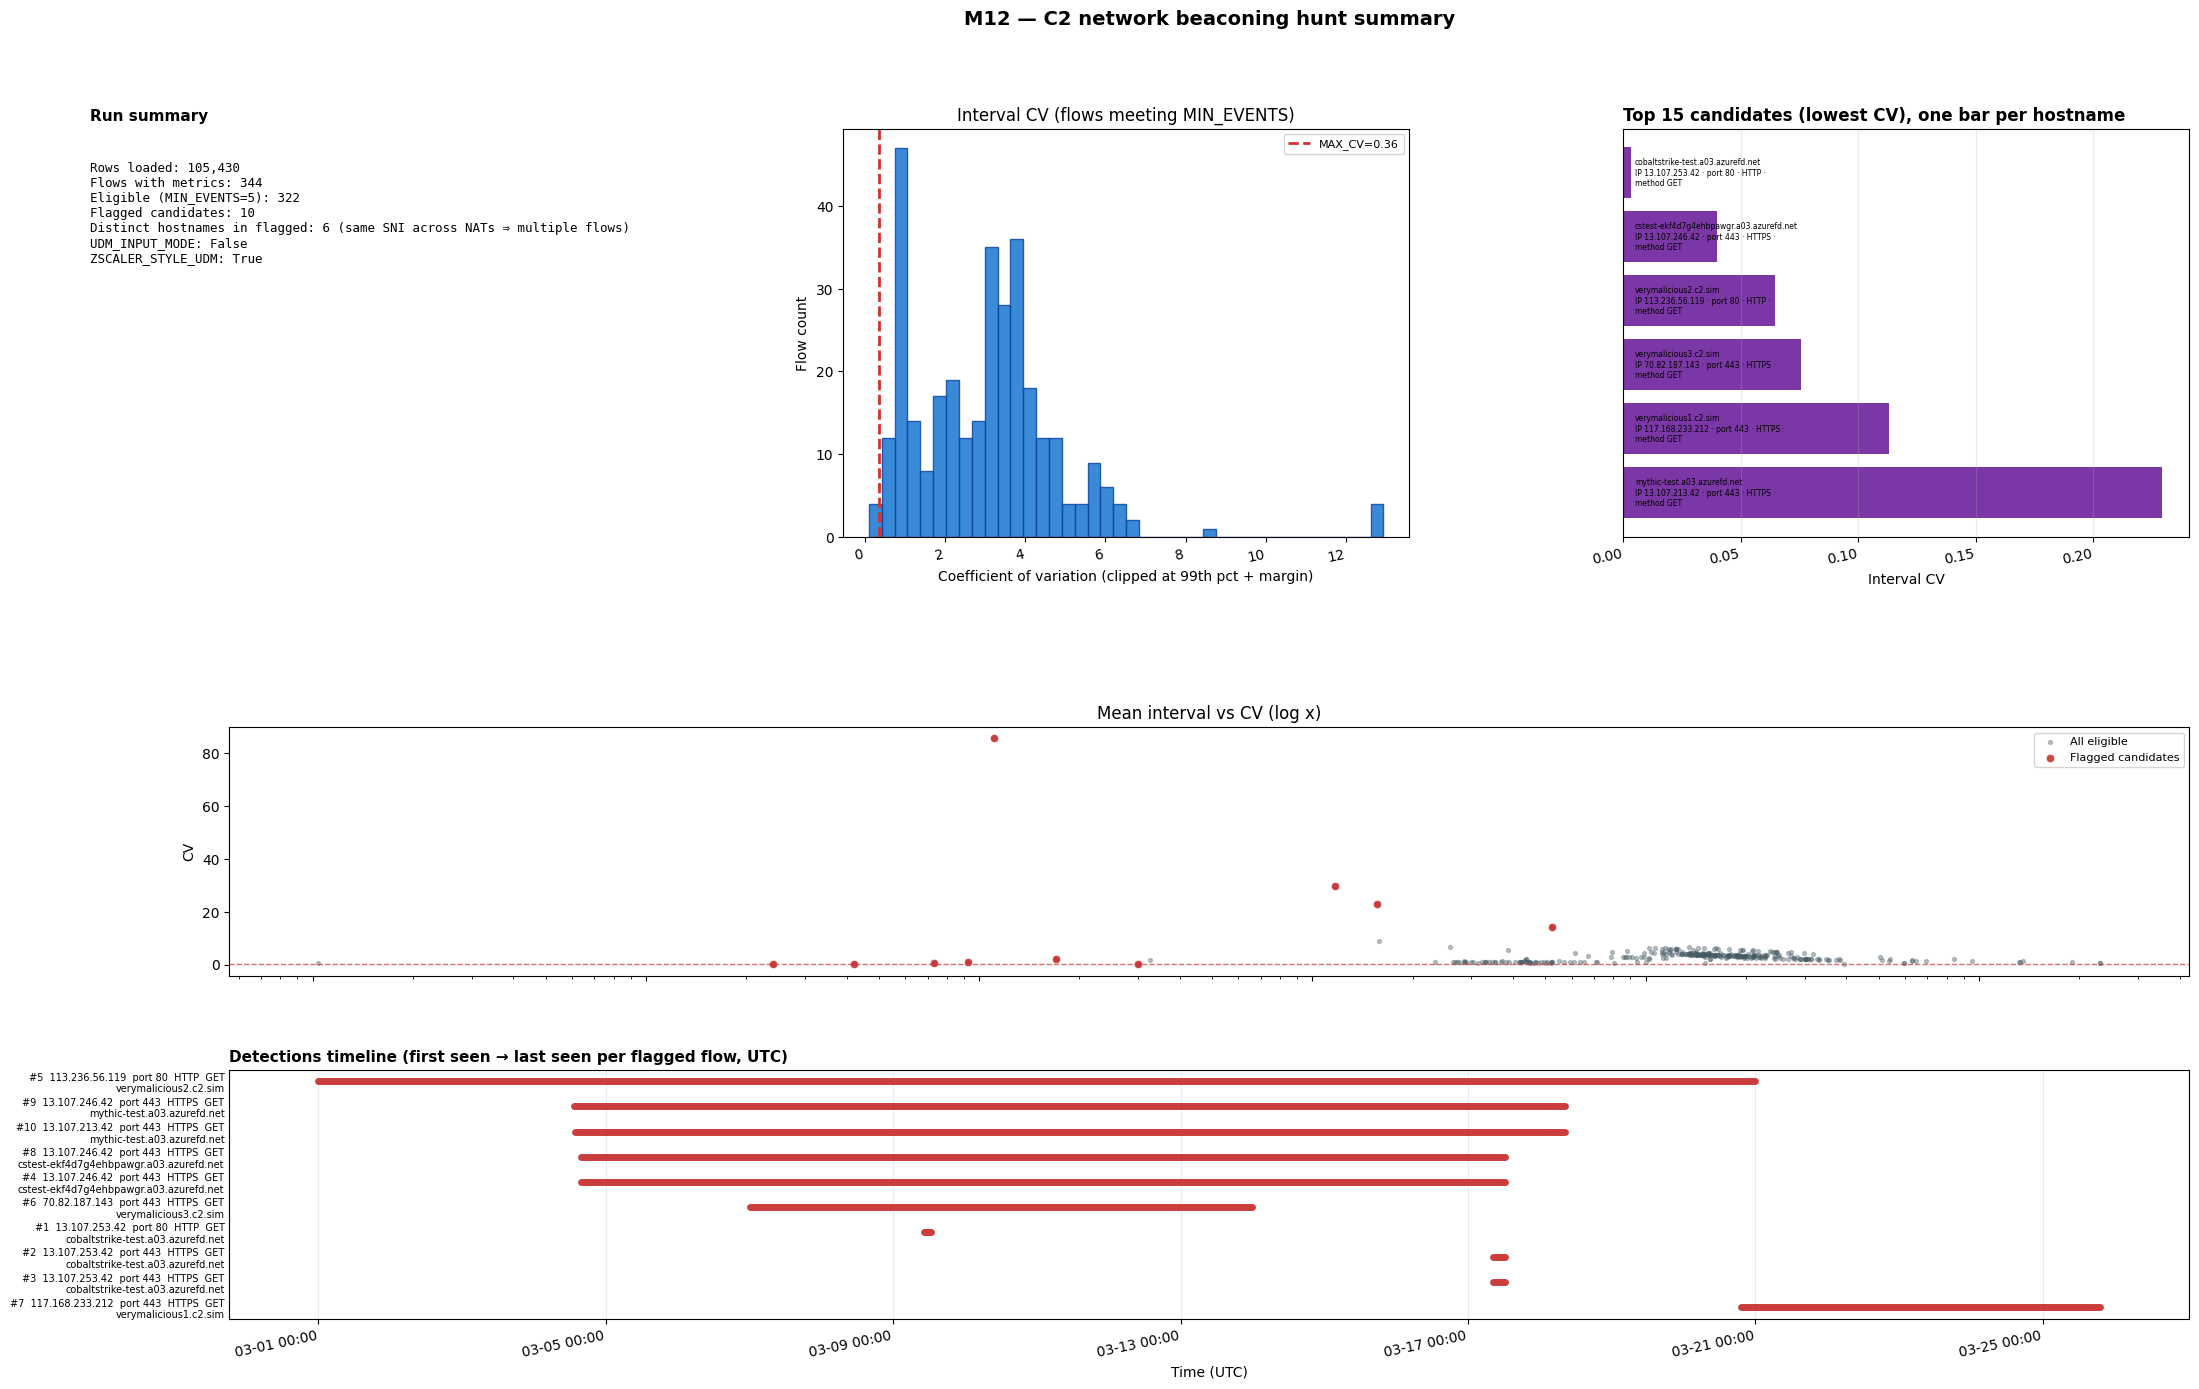

Saved chart to scenarios\detection_of_c2_network_beaconing\output\c2_network_beaconing_kpis.png


In [27]:
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Bar chart: keep one row per destination hostname (lowest CV among flagged flows). Set False to show one bar per flow.
KPI_TOPN_UNIQUE_HOSTNAME = True


def _short_flow_label_for_timeline(row) -> str:
    rank = int(getattr(row, 'rank', 0) or 0)
    ip = str(getattr(row, 'dst_ip', '') or '').strip()
    port = int(getattr(row, 'dst_port', 0) or 0)
    proto = str(getattr(row, 'protocol', '') or '').strip().upper() or '?'
    hm = str(getattr(row, 'http_method_sample', '') or '').strip()
    hm_disp = hm.upper() if hm and hm.lower() not in ('nan', 'none') else '—'
    port_s = str(port) if port else '?'
    line_a = f'#{rank}  {ip}  port {port_s}  {proto}  {hm_disp}'
    hn = str(getattr(row, 'dst_hostname_sample', '') or '').strip()
    if hn and hn.lower() not in ('', 'nan', 'none'):
        hn_s = hn[:52] + ('…' if len(hn) > 52 else '')
        return f'{line_a}\n{hn_s}'
    return line_a


def _plot_detections_timeline_ax(ax, candidates_df: pd.DataFrame, *, max_rows: int = 45, title: str | None = None):
    """Horizontal segments from first_seen to last_seen for each flagged flow (UTC)."""
    t = title or 'Detections timeline (first seen → last seen per flagged flow, UTC)'
    ax.set_title(t, fontsize=11, fontweight='bold', loc='left')
    if candidates_df is None or len(candidates_df) == 0:
        ax.text(0.5, 0.5, 'No flagged candidates', ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    dfc = candidates_df.sort_values('first_seen', ascending=True).head(int(max_rows)).reset_index(drop=True)
    n = len(dfc)
    fs = pd.to_datetime(dfc['first_seen'], utc=True, errors='coerce')
    ls = pd.to_datetime(dfc['last_seen'], utc=True, errors='coerce')
    y = np.arange(n)
    for i in range(n):
        if pd.isna(fs.iloc[i]) or pd.isna(ls.iloc[i]):
            continue
        ax.plot([fs.iloc[i], ls.iloc[i]], [i, i], color='#C62828', linewidth=5, solid_capstyle='round', alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels([_short_flow_label_for_timeline(r) for r in dfc.itertuples(index=False)], fontsize=7)
    ax.set_xlabel('Time (UTC)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(axis='y', length=0)
    ax.invert_yaxis()
    if len(candidates_df) > n:
        ax.text(
            0.99,
            0.02,
            f'Showing {n} of {len(candidates_df):,} candidates',
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=8,
            color='#555555',
        )


eligible = flows_df.copy()
if EXCLUDE_PROTOCOLS:
    eligible = eligible[~eligible['protocol'].isin({p.lower() for p in EXCLUDE_PROTOCOLS})]
eligible = eligible[eligible['n_events'] >= MIN_EVENTS]

_dist_host_flagged = 0
if len(candidates) > 0:
    _hser = candidates['dst_hostname_sample'].fillna('').astype(str).str.strip().str.lower()
    _hser = _hser.replace({'', 'nan', 'none'}, pd.NA)
    _dist_host_flagged = int(_hser.dropna().nunique())

summary_lines = [
    f'Rows loaded: {len(raw):,}',
    f'Flows with metrics: {len(flows_df):,}',
    f'Eligible (MIN_EVENTS={MIN_EVENTS}): {len(eligible):,}',
    f'Flagged candidates: {len(candidates):,}',
    f'Distinct hostnames in flagged: {_dist_host_flagged:,} (same SNI across NATs ⇒ multiple flows)',
    f'UDM_INPUT_MODE: {globals().get("UDM_INPUT_MODE", False)}',
    f'ZSCALER_STYLE_UDM: {globals().get("ZSCALER_STYLE_UDM", False)}',
]

fig = plt.figure(figsize=(20, 14))
fig.suptitle('M12 — C2 network beaconing hunt summary', fontsize=14, fontweight='bold', y=0.985)
# Top: 3-up ribbon. Bottom: one full-width column for scatter + timeline (same width as each other, symmetric L/R).
gs = fig.add_gridspec(
    2,
    1,
    height_ratios=[1.45, 2.1],
    left=0.01,
    right=0.99,
    top=0.90,
    bottom=0.05,
    hspace=0.38,
)
gs_top = gs[0].subgridspec(1, 3, width_ratios=[24, 34, 34], wspace=0.42)
gs_main = gs[1].subgridspec(2, 1, height_ratios=[1.05, 1.05], hspace=0.38)
ax_sum = fig.add_subplot(gs_top[0, 0])
ax0 = fig.add_subplot(gs_top[0, 1])
ax_bar = fig.add_subplot(gs_top[0, 2])
ax1 = fig.add_subplot(gs_main[0, 0])
ax_timeline = fig.add_subplot(gs_main[1, 0])

ax_sum.axis('off')
ax_sum.set_title('Run summary', loc='left', fontsize=11, fontweight='bold', x=-0.35)
ax_sum.text(
    -0.35,
    0.92,
    '\n'.join(summary_lines),
    transform=ax_sum.transAxes,
    va='top',
    ha='left',
    fontsize=9,
    family='monospace',
    clip_on=False,
)

if len(eligible) > 0:
    cv_vals = eligible['interval_cv'].replace([np.inf, -np.inf], np.nan).dropna()
    if len(cv_vals) == 0:
        ax0.text(0.5, 0.5, 'No finite CV values', ha='center', va='center', transform=ax0.transAxes)
    else:
        hi = float(np.nanpercentile(cv_vals, 99)) if len(cv_vals) > 2 else float(cv_vals.max())
        cv_clip = np.clip(cv_vals, 0, hi + 0.01)
        ax0.hist(cv_clip, bins=40, color='#1976D2', edgecolor='#0D47A1', alpha=0.85)
        ax0.axvline(MAX_CV, color='#D32F2F', linestyle='--', linewidth=2, label=f'MAX_CV={MAX_CV}')
        ax0.set_title('Interval CV (flows meeting MIN_EVENTS)')
        ax0.set_xlabel('Coefficient of variation (clipped at 99th pct + margin)')
        ax0.set_ylabel('Flow count')
        ax0.legend(loc='upper right', fontsize=8)
else:
    ax0.text(0.5, 0.5, 'No eligible flows', ha='center', va='center', transform=ax0.transAxes)

if len(eligible) > 0:
    _m = np.isfinite(eligible['interval_mean_s']) & np.isfinite(eligible['interval_cv'])
    x = eligible.loc[_m, 'interval_mean_s']
    y = eligible.loc[_m, 'interval_cv']
    ax1.scatter(x, y, s=8, alpha=0.35, c='#455A64', label='All eligible')
    if len(candidates) > 0:
        cm = np.isfinite(candidates['interval_mean_s']) & np.isfinite(candidates['interval_cv'])
        ax1.scatter(
            candidates.loc[cm, 'interval_mean_s'],
            candidates.loc[cm, 'interval_cv'],
            s=36,
            alpha=0.85,
            c='#C62828',
            edgecolors='white',
            linewidths=0.5,
            label='Flagged candidates',
        )
    ax1.axhline(MAX_CV, color='#D32F2F', linestyle='--', linewidth=1, alpha=0.7)
    ax1.set_xscale('log')
    ax1.set_title('Mean interval vs CV (log x)')
    ax1.set_xlabel('Mean inter-arrival (s)')
    ax1.set_ylabel('CV')
    ax1.legend(loc='upper right', fontsize=8)
else:
    ax1.text(0.5, 0.5, 'No eligible flows', ha='center', va='center', transform=ax1.transAxes)


def _bar_label_for_candidate(row, topn_df: pd.DataFrame, wrap: int = 78) -> str:
    """Hostname (wrapped) + IP, port, L7 protocol, HTTP method; multi-IP note when hostname repeats in top-N."""
    hn = str(getattr(row, 'dst_hostname_sample', '') or '').strip()
    ip = str(row.dst_ip)
    port = int(getattr(row, 'dst_port', 0) or 0)
    proto = str(getattr(row, 'protocol', '') or '').strip().upper() or '?'
    hm = str(getattr(row, 'http_method_sample', '') or '').strip()
    hm_disp = f'method {hm.upper()}' if hm and hm.lower() not in ('nan', 'none') else 'method —'
    port_s = str(port) if port else '?'
    detail = f'IP {ip} · port {port_s} · {proto} · {hm_disp}'
    detail_wrapped = textwrap.fill(detail, width=wrap, break_long_words=False, break_on_hyphens=True)
    if hn.lower() in ('', 'nan', 'none'):
        return detail_wrapped
    hn_block = textwrap.fill(hn, width=wrap, break_long_words=False, break_on_hyphens=True)
    same = topn_df[topn_df['dst_hostname_sample'].astype(str).str.strip().str.lower() == hn.lower()]
    ips = sorted(same['dst_ip'].astype(str).unique())
    if len(ips) > 1:
        ip_note = 'Public IPs in top-15 (same hostname): ' + ', '.join(ips)
        ip_note = textwrap.fill(ip_note, width=wrap, break_long_words=False, break_on_hyphens=True)
        return ip_note + '\n' + detail_wrapped + '\n' + hn_block
    return hn_block + '\n' + detail_wrapped


if len(candidates) > 0:
    _pcv = np.nanmin(
        np.column_stack(
            [
                candidates['interval_cv'].to_numpy(dtype=float),
                np.where(np.isfinite(candidates['interval_cv_band']), candidates['interval_cv_band'], np.nan),
                np.where(np.isfinite(candidates['interval_cv_slow']), candidates['interval_cv_slow'], np.nan),
            ]
        ),
        axis=1,
    )
    topn = candidates.assign(_plot_cv=_pcv).sort_values('_plot_cv', ascending=True)
    if KPI_TOPN_UNIQUE_HOSTNAME:

        def _bar_dedupe_key(r) -> str:
            hn = str(getattr(r, 'dst_hostname_sample', '') or '').strip().lower()
            if hn and hn not in ('nan', 'none'):
                return hn
            return f'{r.flow_src}\x1f{r.dst_ip}\x1f{r.dst_port}\x1f{r.protocol}'

        topn = topn.assign(_bar_k=[_bar_dedupe_key(r) for r in topn.itertuples(index=False)])
        topn = topn.drop_duplicates(subset=['_bar_k'], keep='first').drop(columns=['_bar_k'])
    topn = topn.head(15)
    labels = [_bar_label_for_candidate(r, topn, wrap=40) for r in topn.itertuples(index=False)]
    y_pos = np.arange(len(labels))
    ax_bar.barh(y_pos, topn['_plot_cv'].values, color='#6A1B9A', alpha=0.88)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels([])
    ax_bar.invert_yaxis()
    x_lim = ax_bar.get_xlim()
    x_pad = (x_lim[1] - x_lim[0]) * 0.02
    for yi, lab in zip(y_pos, labels):
        ax_bar.text(
            x_pad,
            float(yi),
            lab,
            ha='left',
            va='center',
            fontsize=5.5,
            color='black',
            clip_on=True,
        )
    _bar_title = 'Top 15 candidates (lowest CV)'
    if KPI_TOPN_UNIQUE_HOSTNAME:
        _bar_title += ', one bar per hostname'
    ax_bar.set_title(_bar_title, fontsize=12, fontweight='bold', loc='left')
    ax_bar.set_xlabel('Interval CV')
    ax_bar.tick_params(axis='y', length=0)
    ax_bar.grid(axis='x', alpha=0.25)
else:
    ax_bar.text(0.5, 0.5, 'No candidates', ha='center', va='center', transform=ax_bar.transAxes)
    ax_bar.set_title('Top 15 candidates (lowest CV)', fontsize=12, fontweight='bold', loc='left')

_plot_detections_timeline_ax(ax_timeline, candidates)
fig.autofmt_xdate(rotation=12)

chart_path = OUTPUT_DIR / 'c2_network_beaconing_kpis.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
try:
    _ipy = get_ipython()
except NameError:
    _ipy = None
if _ipy is not None:
    plt.show()
plt.close(fig)
print(f'Saved chart to {_rel(chart_path)}')

## Export results

Write ranked rows to **`output/c2_network_beaconing_candidates.csv`** and the KPI figure to **`output/c2_network_beaconing_kpis.png`** for ticketing, enrichment, or fusion with other hunts. **Investigation** should combine these signals with asset criticality, destination reputation, and process/network correlation from your telemetry stack.

In [28]:
out_path = OUTPUT_DIR / 'c2_network_beaconing_candidates.csv'
candidates.to_csv(out_path, index=False)
print(f'Saved {_rel(out_path)} ({len(candidates):,} rows).')

Saved scenarios\detection_of_c2_network_beaconing\output\c2_network_beaconing_candidates.csv (10 rows).


## Export false-positive candidates

Beaconing candidates flagged by the CV/timing rules are not necessarily C2 — many are legitimate **scheduled tasks**, **health checks**, or **software update cadences** with similar regularity. This step produces **`output/c2_network_beaconing_false_positive_candidates.csv`** to help analysts efficiently triage which destinations are benign.

The file contains all candidates enriched with a **`dst_key`** column (destination hostname when available, otherwise destination IP — the value you would add to exclusions). Entries whose `dst_key` appears in **`exclusions/reviewed_values.conf`** are removed so that destinations already confirmed as genuine threats are not re-proposed for exclusion on subsequent runs.

**After reviewing:** add true false positives to `exclusions/excluded_values.conf` and confirmed genuine findings to `exclusions/reviewed_values.conf`.

In [29]:
def _dst_key(row) -> str:
    """Primary destination identifier: hostname if non-empty, otherwise IP."""
    hn = str(getattr(row, 'dst_hostname_sample', '') or '').strip()
    if hn and hn.lower() not in ('', 'nan', 'none'):
        return hn.lower().rstrip('.')
    ip = str(getattr(row, 'dst_ip', '') or '').strip()
    return ip.lower() if ip else ''


def _normalize_values(values) -> set[str]:
    out: set[str] = set()
    for v in values or []:
        s = str(v).strip().lower().rstrip('.')
        if s and s not in {'nan', 'none'}:
            out.add(s)
    return out


fp_candidates_path = OUTPUT_DIR / 'c2_network_beaconing_false_positive_candidates.csv'
fp_summary_path = OUTPUT_DIR / 'c2_network_beaconing_false_positive_summary_by_dst_key.csv'
fp_candidates_path.parent.mkdir(parents=True, exist_ok=True)
_reviewed_values = _normalize_values(globals().get('reviewed_values_cfg', set()))

if len(candidates) > 0:
    fp_df = candidates.copy()
    fp_df['dst_key'] = [_dst_key(r) for r in fp_df.itertuples(index=False)]

    if _reviewed_values:
        before_reviewed = len(fp_df)
        fp_df = fp_df[~fp_df['dst_key'].isin(_reviewed_values)].reset_index(drop=True)
        reviewed_removed = before_reviewed - len(fp_df)
    else:
        reviewed_removed = 0

    fp_df = fp_df.sort_values('rank', ascending=False).reset_index(drop=True)

    fp_output_cols = list(candidates.columns) + ['dst_key']
    fp_df[fp_output_cols].to_csv(fp_candidates_path, index=False)

    fp_summary_agg = {
        'candidate_rows': ('dst_key', 'size'),
        'distinct_dst_ips': ('dst_ip', 'nunique'),
        'protocols': ('protocol', lambda s: ','.join(sorted({str(v).strip().lower() for v in s if str(v).strip()}))),
        'total_n_events': ('n_events', 'sum'),
        'min_rank': ('rank', 'min'),
        'max_rank': ('rank', 'max'),
        'best_interval_cv': ('interval_cv', 'min'),
        'best_interval_cv_band': ('interval_cv_band', 'min'),
        'best_interval_cv_slow': ('interval_cv_slow', 'min'),
    }
    if 'dst_ip_churn' in fp_df.columns:
        fp_summary_agg['min_dst_ip_churn'] = ('dst_ip_churn', 'min')
    if 'tp_likelihood_score' in fp_df.columns:
        fp_summary_agg['max_tp_likelihood_score'] = ('tp_likelihood_score', 'max')
    if 'benign_likelihood_score' in fp_df.columns:
        fp_summary_agg['max_benign_likelihood_score'] = ('benign_likelihood_score', 'max')

    fp_summary_df = (
        fp_df.groupby('dst_key', dropna=False)
        .agg(**fp_summary_agg)
        .reset_index()
        .sort_values(['max_rank', 'candidate_rows'], ascending=[False, False])
        .reset_index(drop=True)
    )
    fp_summary_df.to_csv(fp_summary_path, index=False)

    print(f'False-positive candidates: {len(fp_df):,} entries.')
    if reviewed_removed:
        print(f'Removed {reviewed_removed:,} entries whose dst_key was already reviewed (reviewed_values.conf).')
    print(f'Unique dst_key values: {fp_df["dst_key"].nunique():,}')
    print(f'Saved to {_rel(fp_candidates_path)}')
    print(f'Saved summary to {_rel(fp_summary_path)}')
    _fp_preview_cols = [
        'dst_key', 'dst_ip', 'dst_port', 'protocol', 'dst_hostname_sample',
        'n_events', 'interval_cv', 'interval_cv_band', 'interval_cv_slow',
        'dst_ip_churn', 'tp_likelihood_score', 'benign_likelihood_score', 'rank'
    ]
    _fp_preview_cols = [c for c in _fp_preview_cols if c in fp_df.columns]
    display(fp_df[_fp_preview_cols].head(20))
    display(fp_summary_df.head(20))
else:
    fp_output_cols = list(candidates.columns) + ['dst_key']
    fp_df = pd.DataFrame(columns=fp_output_cols)
    fp_df.to_csv(fp_candidates_path, index=False)

    fp_summary_cols = [
        'dst_key',
        'candidate_rows',
        'distinct_dst_ips',
        'protocols',
        'total_n_events',
        'min_rank',
        'max_rank',
        'best_interval_cv',
        'best_interval_cv_band',
        'best_interval_cv_slow',
        'min_dst_ip_churn',
        'max_tp_likelihood_score',
        'max_benign_likelihood_score',
    ]
    pd.DataFrame(columns=fp_summary_cols).to_csv(fp_summary_path, index=False)
    print(f'No candidates — empty false-positive candidates file saved to {_rel(fp_candidates_path)}')
    print(f'No candidates — empty destination summary file saved to {_rel(fp_summary_path)}')

False-positive candidates: 10 entries.
Unique dst_key values: 6
Saved to scenarios\detection_of_c2_network_beaconing\output\c2_network_beaconing_false_positive_candidates.csv
Saved summary to scenarios\detection_of_c2_network_beaconing\output\c2_network_beaconing_false_positive_summary_by_dst_key.csv


,dst_key,dst_ip,dst_port,protocol,dst_hostname_sample,n_events,interval_cv,interval_cv_band,interval_cv_slow,dst_ip_churn,tp_likelihood_score,benign_likelihood_score,rank
0,mythic-test.a03.azurefd.net,13.107.213.42,443,https,mythic-test.a03.azurefd.net,228,14.027756,0.229370,0.379358,0.043860,0.596702,0.477358,10
1,mythic-test.a03.azurefd.net,13.107.246.42,443,https,mythic-test.a03.azurefd.net,1021,29.785272,0.235364,0.321507,0.013712,0.640676,0.473093,9
2,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,13.107.246.42,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,713,22.784304,0.140444,0.498293,0.004208,0.727884,0.333431,8
3,verymalicious1.c2.sim,117.168.233.212,443,https,verymalicious1.c2.sim,1446,0.113178,NaN,0.113178,0.002766,0.749731,0.339308,7
4,verymalicious3.c2.sim,70.82.187.143,443,https,verymalicious3.c2.sim,25130,0.345068,NaN,0.075645,0.000159,0.812177,0.304105,6
5,verymalicious2.c2.sim,113.236.56.119,80,http,verymalicious2.c2.sim,41153,0.102707,0.064361,0.102707,0.000097,0.817820,0.297898,5
6,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,13.107.246.42,443,https,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,10046,85.466515,0.039630,0.242067,0.000299,0.846852,0.255130,4
7,cobaltstrike-test.a03.azurefd.net,13.107.253.42,443,https,cobaltstrike-test.a03.azurefd.net,87,2.262965,0.004557,0.446896,0.011494,0.855422,0.049939,3
8,cobaltstrike-test.a03.azurefd.net,13.107.253.42,443,https,cobaltstrike-test.a03.azurefd.net,164,0.865502,0.041497,0.394344,0.006098,0.859093,0.062876,2
9,cobaltstrike-test.a03.azurefd.net,13.107.253.42,80,http,cobaltstrike-test.a03.azurefd.net,108,0.616687,0.003362,0.366791,0.009259,0.863558,0.046769,1


,dst_key,candidate_rows,distinct_dst_ips,protocols,total_n_events,min_rank,max_rank,best_interval_cv,best_interval_cv_band,best_interval_cv_slow,min_dst_ip_churn,max_tp_likelihood_score,max_benign_likelihood_score
0,mythic-test.a03.azurefd.net,2,2,https,1249,9,10,14.027756,0.229370,0.321507,0.013712,0.640676,0.477358
1,cstest-ekf4d7g4ehbpawgr.a03.azurefd.net,2,1,https,10759,4,8,22.784304,0.039630,0.242067,0.000299,0.846852,0.333431
2,verymalicious1.c2.sim,1,1,https,1446,7,7,0.113178,NaN,0.113178,0.002766,0.749731,0.339308
3,verymalicious3.c2.sim,1,1,https,25130,6,6,0.345068,NaN,0.075645,0.000159,0.812177,0.304105
4,verymalicious2.c2.sim,1,1,http,41153,5,5,0.102707,0.064361,0.102707,0.000097,0.817820,0.297898
5,cobaltstrike-test.a03.azurefd.net,3,1,"http,https",359,1,3,0.616687,0.003362,0.366791,0.006098,0.863558,0.062876


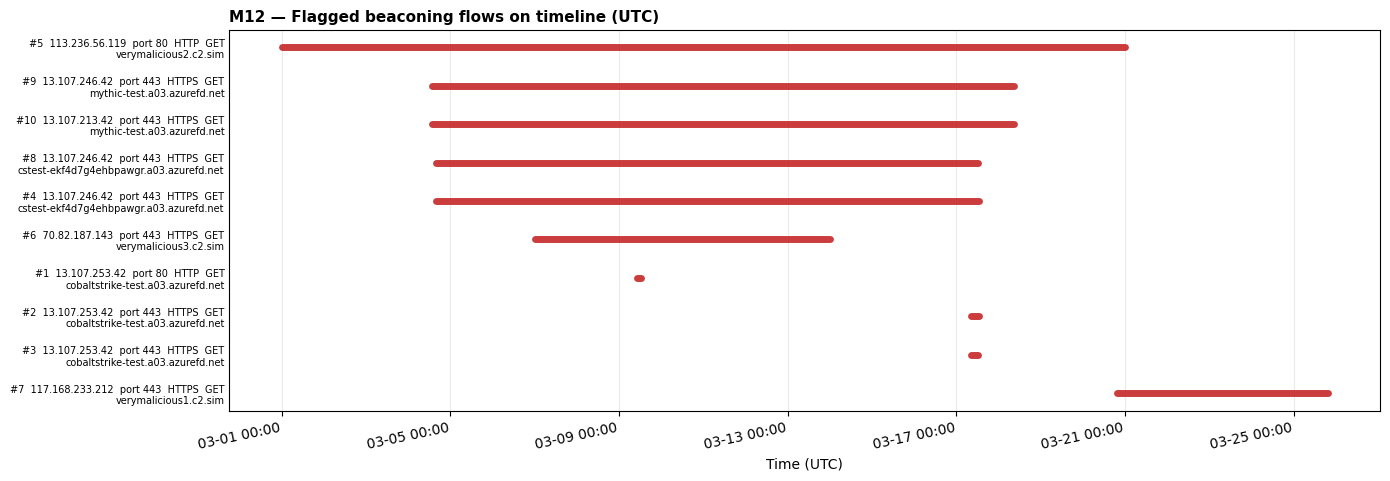

In [30]:
# Detections timeline (same data as the bottom panel of c2_network_beaconing_kpis.png)
_tl_n = min(len(candidates), 50) if len(candidates) else 1
fig_timeline_only, ax_tl = plt.subplots(figsize=(14, min(max(4.0, 0.32 * _tl_n + 2.0), 22)))
_plot_detections_timeline_ax(
    ax_tl,
    candidates,
    max_rows=50,
    title='M12 — Flagged beaconing flows on timeline (UTC)',
)
plt.tight_layout()
fig_timeline_only.autofmt_xdate(rotation=12)
try:
    _ipy_tl = get_ipython()
except NameError:
    _ipy_tl = None
if _ipy_tl is not None:
    plt.show()
plt.close(fig_timeline_only)

## KNOWLEDGE — Continuous Improvement

- **Re-Add Topics to Backlog:** New beaconing patterns, unusual protocols, or destination clusters discovered during analysis become future hunt hypotheses.
- **Communicate Findings:** Share confirmed C2 channels and near-miss candidates with SOC leadership and incident response teams.
- **Feed Improvements Back:** Add confirmed benign periodic flows to exclusion lists; tune CV thresholds and interval bounds based on observed true/false positive rates; update RITA-style gates as the environment evolves.
- **Measure Effectiveness:** Compare candidate counts, exclusion rates, and confirmed C2 detections across successive runs to track detection maturity.